# Эксперимент

**Гипотеза**. Использование одной модели для валидации вносит алгоритмическую предвзятость. 
Данные будут соответствовать паттернам рассуждения этой сети, что может исказить объективность.

In [1]:
%pip install -q networkx pydantic httpx python-dotenv matplotlib seaborn pandas

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os, sys, json, logging
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()

ROOT = Path('.').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)-8s | %(name)s | %(message)s',
)
logger = logging.getLogger('notebook')
logger.info('Environment ready. ROOT=%s', ROOT)


2026-05-27 06:54:17,444 | INFO     | notebook | Environment ready. ROOT=/home/timichis/Documents/research_proposal/experiment


---
## § 1 · Проверка конфигурации API

In [2]:
from src.config import MODEL_CONFIGS, ALL_MODELS
for model_key, cfg in MODEL_CONFIGS.items():
    key_status = 'SET' if cfg.api_key else 'MISSING'
    print(f'{model_key:25s}  key={key_status}  url={cfg.base_url}  rpm={cfg.requests_per_minute}')


qwen3-235b-a22b            key=SET  url=https://ai.api.cloud.yandex.net/v1  rpm=100
gpt-oss-120b               key=SET  url=https://ai.api.cloud.yandex.net/v1  rpm=100
deepseek-3.2               key=SET  url=https://ai.api.cloud.yandex.net/v1  rpm=100


---
## § 2 · Генерация датасета DAG


In [3]:
from src.config import GRAPH_CONFIG, GRAPHS_FILE
from src.dag_generator import generate_dataset, save_graphs
import networkx as nx
import matplotlib.pyplot as plt

graphs = generate_dataset(GRAPH_CONFIG)
save_graphs(graphs, GRAPHS_FILE)

print(f'Generated {len(graphs)} DAGs -> {GRAPHS_FILE}')
g = graphs[0]
print(f'\nFirst graph:  {len(g.nodes)} nodes, {len(g.edge_set())} edges')
print(f'Intent: {g.task_intent}')
for n in g.nodes:
    print(f'  [{n.label}] {n.description}')


2026-05-27 06:54:20,395 | INFO     | src.dag_generator | Generating 50 DAGs (seed=42)…
2026-05-27 06:54:20,397 | INFO     | src.dag_generator |   … 10/50 DAGs generated
2026-05-27 06:54:20,399 | INFO     | src.dag_generator |   … 20/50 DAGs generated
2026-05-27 06:54:20,401 | INFO     | src.dag_generator |   … 30/50 DAGs generated
2026-05-27 06:54:20,403 | INFO     | src.dag_generator |   … 40/50 DAGs generated
2026-05-27 06:54:20,405 | INFO     | src.dag_generator |   … 50/50 DAGs generated
2026-05-27 06:54:20,405 | INFO     | src.dag_generator | Dataset generation complete: 50 graphs.
2026-05-27 06:54:20,408 | INFO     | src.dag_generator | Saved 50 graphs → /home/timichis/Documents/research_proposal/experiment/data/graphs.json


Generated 50 DAGs -> /home/timichis/Documents/research_proposal/experiment/data/graphs.json

First graph:  9 nodes, 10 edges
Intent: Starting from [normalize_columns], complete the workflow ending at [setup_environment]
  [normalize_columns] Scale numeric columns to the [0, 1] range using min-max normalization
  [fetch_data] Retrieve the raw dataset from the remote storage endpoint
  [run_migrations] Apply all pending schema migration scripts to the database
  [tune_hyperparams] Run a grid search to find the optimal hyperparameter configuration
  [evaluate_model] Compute accuracy, precision, recall, and F1 on the validation subset
  [run_smoke_tests] Execute a suite of lightweight smoke tests against the live API
  [encode_categoricals] Apply one-hot encoding to all categorical feature columns
  [generate_dashboard] Render a real-time monitoring dashboard in Grafana
  [setup_environment] Install required Python packages from the requirements file


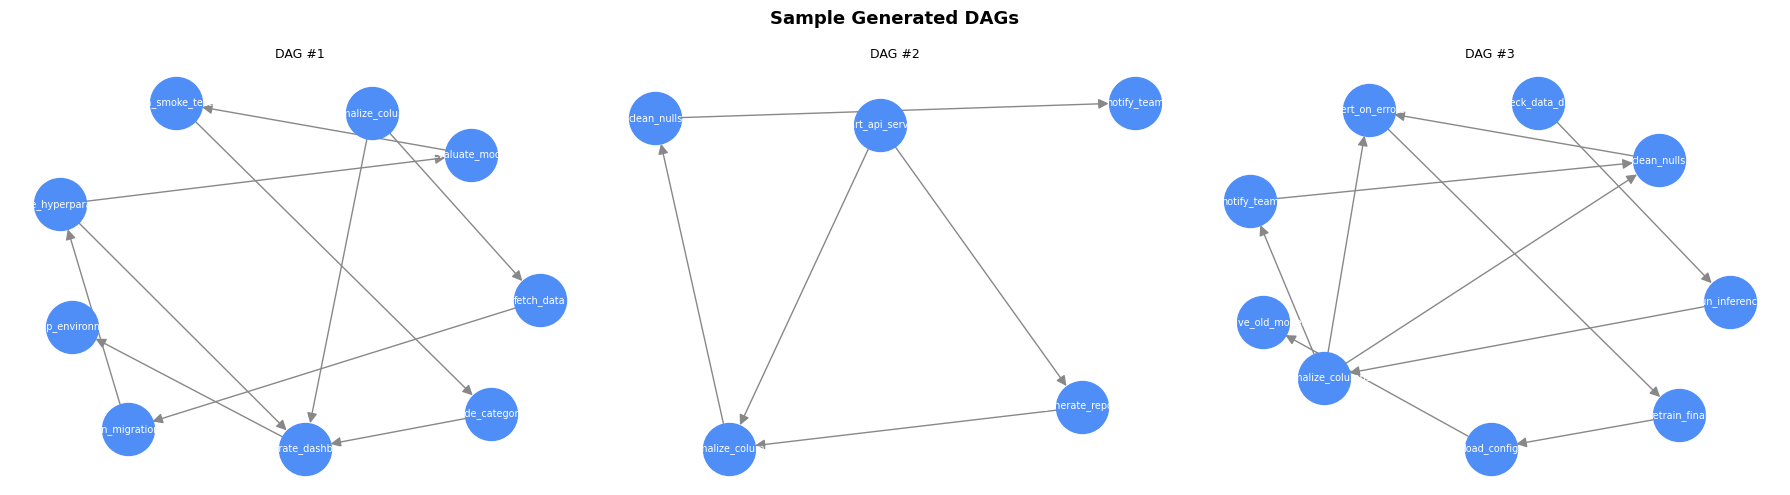

In [4]:
def visualize_dag(dag, ax, title=''):
    G = nx.DiGraph()
    lmap = dag.node_label_map()
    for nid in dag.node_ids():
        G.add_node(nid, label=lmap[nid])
    for src, dsts in dag.edges.items():
        for dst in dsts:
            G.add_edge(src, dst)
    pos = nx.spring_layout(G, seed=42, k=2.5)
    labels = {n: lmap[n] for n in G.nodes()}
    nx.draw_networkx(G, pos=pos, labels=labels, ax=ax,
                     node_color='#4f8ef7', node_size=1400, font_color='white',
                     font_size=7, edge_color='#888', arrows=True, arrowsize=15)
    ax.set_title(title, fontsize=9); ax.axis('off')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Sample Generated DAGs', fontsize=13, fontweight='bold')
for i, ax in enumerate(axes):
    visualize_dag(graphs[i], ax, f'DAG #{i+1}')
plt.tight_layout()
Path('results').mkdir(exist_ok=True)
plt.savefig('results/sample_dags.png', dpi=150, bbox_inches='tight')
plt.show()


---
## § 3 · Этап суммаризации


In [6]:
from src.instruction_generator import (
    run_summarization_stage, save_instructions, load_instructions
)
from src.config import INSTRUCTIONS_FILE, ALL_MODELS

instructions = load_instructions(INSTRUCTIONS_FILE)

instructions = await run_summarization_stage(
    graphs=graphs, models=ALL_MODELS, concurrency_per_model=10
)
save_instructions(instructions, INSTRUCTIONS_FILE)

by_model = {}
for instr in instructions:
    by_model.setdefault(instr.generator_model, []).append(instr)
print(f'Total: {len(instructions)} instructions')
for model, instrs in by_model.items():
    acc = sum(1 for i in instrs if i.accepted)
    avg_f1 = sum(i.consistency_score for i in instrs) / len(instrs)
    print(f'  {model}: {acc}/{len(instrs)} accepted, avg F1={avg_f1:.3f}')


2026-05-27 06:55:04,527 | INFO     | src.instruction_generator | Loaded 150 instructions ← /home/timichis/Documents/research_proposal/experiment/data/instructions.json
2026-05-27 06:55:04,528 | INFO     | src.instruction_generator | [gpt-oss-120b] Generating instructions for 50 graphs…
2026-05-27 06:55:08,229 | INFO     | httpx | HTTP Request: POST https://ai.api.cloud.yandex.net/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-27 06:55:09,356 | INFO     | httpx | HTTP Request: POST https://ai.api.cloud.yandex.net/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-27 06:55:09,970 | INFO     | httpx | HTTP Request: POST https://ai.api.cloud.yandex.net/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-27 06:55:09,971 | INFO     | httpx | HTTP Request: POST https://ai.api.cloud.yandex.net/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-27 06:55:10,477 | INFO     | httpx | HTTP Request: POST https://ai.api.cloud.yandex.net/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-27 06:55:10,677 | INFO     | httpx 

Total: 150 instructions
  gpt-oss-120b: 40/50 accepted, avg F1=0.827
  deepseek-3.2: 27/50 accepted, avg F1=0.611
  qwen3-235b-a22b: 47/50 accepted, avg F1=0.923


In [7]:
s = instructions[106]
print(f'Graph:    {s.graph_id}')
print(f'Model:    {s.generator_model}')
print(f'F1:       {s.consistency_score:.3f}')
print(f'Attempts: {s.generation_attempts}')
print(f'\n{s.task_instruction}')


Graph:    c58fb2f7-58f0-45c5-9ac0-6e41fd31ea18
Model:    qwen3-235b-a22b
F1:       0.933
Attempts: 1

Start by triggering a PagerDuty alert if the error rate exceeds the threshold. Once that is done, save the model predictions to a CSV file in the output directory. After the predictions are exported, remove or impute all null and missing values from the dataset. Meanwhile, once the alert has been triggered and the predictions exported, begin applying all pending schema migration scripts to the database — this step can proceed as soon as those two tasks are complete. Finally, once the alert has been triggered, the nulls have been cleaned, and the migrations have finished, record all experiment metadata to the MLflow tracking server. Note that some steps run in sequence and others in parallel: exporting predictions follows the alert, cleaning nulls follows export, and both migrations and logging depend on prior completion of the alert, export, and cleaning steps, with logging being the f

---
## § 4 · Этап реконструкции

In [8]:
from src.graph_reconstructor import (
    run_reconstruction_stage, save_reconstructions
)
from src.config import RECONSTRUCTIONS_FILE

# rec_results = load_reconstructions(RECONSTRUCTIONS_FILE)

rec_results = await run_reconstruction_stage(
    instructions=instructions, graphs=graphs,
    models=ALL_MODELS, concurrency_per_model=10,
)
save_reconstructions(rec_results, RECONSTRUCTIONS_FILE)

parse_ok = sum(1 for r in rec_results if r.parse_success)
print(f'Total: {len(rec_results)} results, parse success: {parse_ok}/{len(rec_results)}')


2026-05-27 07:16:53,357 | INFO     | src.graph_reconstructor | [gpt-oss-120b] Starting reconstruction of 150 instructions…
2026-05-27 07:16:54,000 | INFO     | httpx | HTTP Request: POST https://ai.api.cloud.yandex.net/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-27 07:16:54,720 | INFO     | httpx | HTTP Request: POST https://ai.api.cloud.yandex.net/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-27 07:16:55,035 | INFO     | httpx | HTTP Request: POST https://ai.api.cloud.yandex.net/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-27 07:17:01,788 | INFO     | httpx | HTTP Request: POST https://ai.api.cloud.yandex.net/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-27 07:17:02,252 | INFO     | httpx | HTTP Request: POST https://ai.api.cloud.yandex.net/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-27 07:17:02,464 | INFO     | httpx | HTTP Request: POST https://ai.api.cloud.yandex.net/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-27 07:17:02,557 | INFO     | httpx | HTTP Request: POST https://a

Total: 450 results, parse success: 350/450


---
## § 5 · Метрики и кросс-матрица


In [9]:
from src.evaluator import save_metrics, build_cross_matrix

matrix = save_metrics(rec_results, graphs, ALL_MODELS)


2026-05-27 07:33:29,874 | INFO     | src.evaluator | Cross-matrix built: 9 cells
2026-05-27 07:33:29,885 | INFO     | src.evaluator | Cross-matrix saved → /home/timichis/Documents/research_proposal/experiment/results/cross_matrix.json
2026-05-27 07:33:29,886 | INFO     | src.evaluator | Report saved → /home/timichis/Documents/research_proposal/experiment/results/report.md



CROSS-MODEL BIAS EXPERIMENT — Edge F1 Cross-Matrix

                                gpt-oss-120b  deepseek-3.2qwen3-235b-a22b
------------------------------------------------------------------------
gpt-oss-120b                           0.786         0.254         0.801
deepseek-3.2                           0.614         0.431         0.605
qwen3-235b-a22b                        0.689         0.120         0.915

                                  [F1 score]    [F1 score]    [F1 score]

Diagonal cells (gen == rec) indicate potential self-resonance bias.


Metric Details
Gen                  Rec                    Prec    Rec     F1    EM%     N
----------------------------------------------------------------------
gpt-oss-120b         gpt-oss-120b          0.840  0.751  0.786  50.0%    50
gpt-oss-120b         deepseek-3.2          0.260  0.250  0.254  22.0%    50
gpt-oss-120b         qwen3-235b-a22b       0.863  0.763  0.801  46.0%    50
deepseek-3.2         gpt-oss-120b          0.6

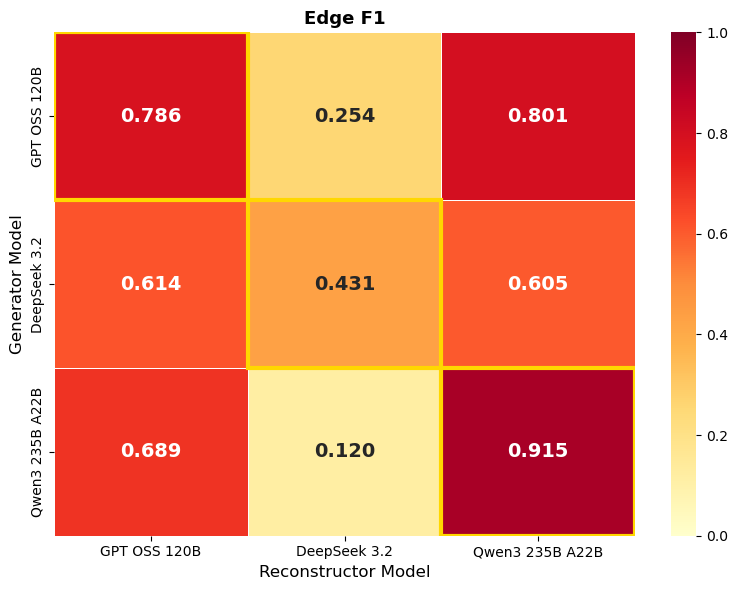

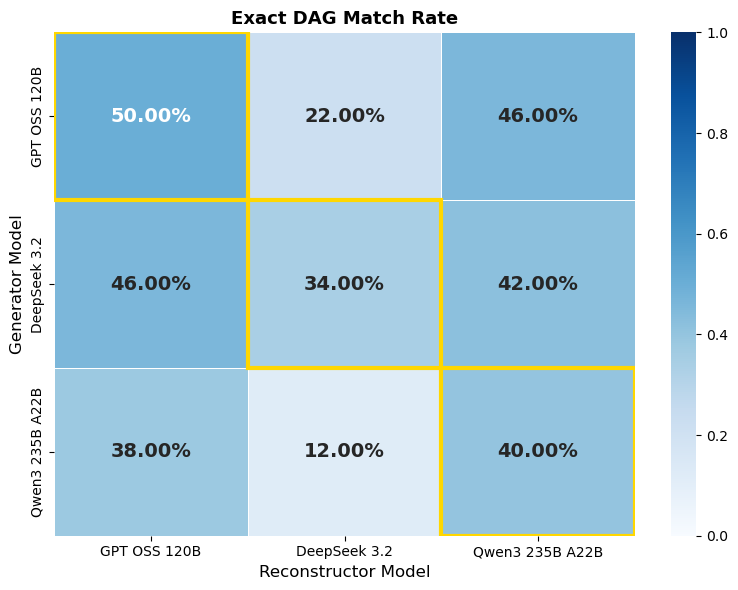

In [17]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SHORT = {
    'gpt-oss-120b': 'GPT OSS 120B',
    'qwen3-235b-a22b': 'Qwen3 235B A22B',
    'deepseek-3.2': 'DeepSeek 3.2',
}

def plot_heatmap(matrix, attr, title, fmt='.3f', cmap='YlOrRd', vmin=0, vmax=1):
    models = matrix.models
    data = np.zeros((len(models), len(models)))
    for i, gen in enumerate(models):
        for j, rec in enumerate(models):
            cell = matrix.get(gen, rec)
            data[i, j] = getattr(cell, attr) if cell else 0.0
    labels = [SHORT.get(m, m) for m in models]
    df = pd.DataFrame(data, index=labels, columns=labels)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(df, annot=True, fmt=fmt, cmap=cmap, vmin=vmin, vmax=vmax,
                linewidths=0.5, ax=ax, annot_kws={'size': 14, 'weight': 'bold'})
    for k in range(len(models)):
        ax.add_patch(plt.Rectangle((k, k), 1, 1, fill=False,
                                    edgecolor='#FFD700', lw=3, zorder=5))
    ax.set_xlabel('Reconstructor Model', fontsize=12)
    ax.set_ylabel('Generator Model', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    return fig

fig1 = plot_heatmap(matrix, 'avg_f1', 'Edge F1')
fig1.savefig('results/cross_matrix_f1.png', dpi=150, bbox_inches='tight')
plt.show()

fig2 = plot_heatmap(matrix, 'exact_match_rate', 'Exact DAG Match Rate',
                    fmt='.2%', cmap='Blues')
fig2.savefig('results/cross_matrix_em.png', dpi=150, bbox_inches='tight')
plt.show()


---
## § 6 · Количественный анализ гипотезы


In [18]:
models = matrix.models
diag, off = [], []
for gen in models:
    for rec in models:
        cell = matrix.get(gen, rec)
        if not cell: continue
        (diag if gen == rec else off).append(cell.avg_f1)

avg_d, avg_o = sum(diag)/len(diag), sum(off)/len(off)
delta = avg_d - avg_o
print(f'Avg diagonal F1    : {avg_d:.4f}')
print(f'Avg off-diagonal F1: {avg_o:.4f}')
print(f'Delta (bias): {delta:+.4f}')
msg = ('Bias detected' if delta > 0.05
       else 'Marginal signal' if delta > 0.02
       else 'No significant bias')
print(f'\n>>> {msg}')


Avg diagonal F1    : 0.7106
Avg off-diagonal F1: 0.5138
Delta (bias): +0.1969

>>> Bias detected


In [19]:
from src.evaluator import generate_markdown_report
report = generate_markdown_report(matrix)
Path('results/report.md').write_text(report, encoding='utf-8')


1727

---
## § 7 · Распределение F1 по ячейкам (violin plot)


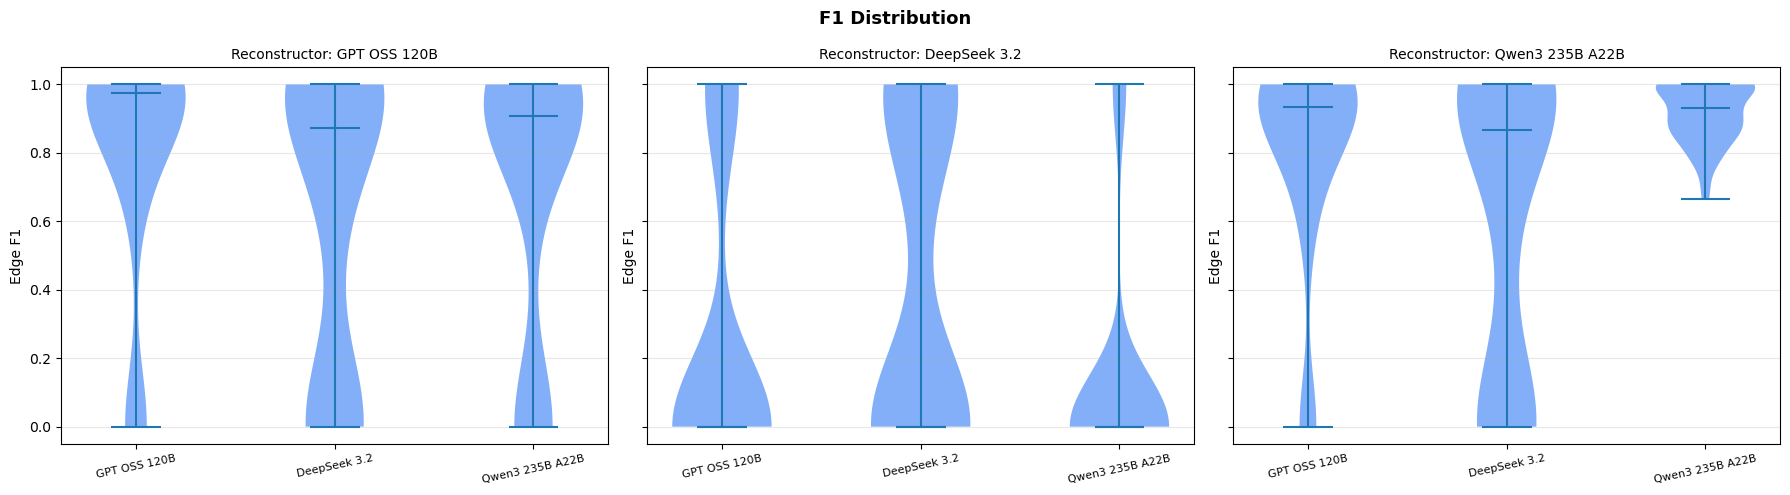

In [20]:
from src.evaluator import compute_edge_metrics

graph_index = {g.graph_id: g for g in graphs}
all_metrics = [compute_edge_metrics(r, graph_index) for r in rec_results]

rows = [{'gen': SHORT.get(m.generator_model, m.generator_model),
         'rec': SHORT.get(m.reconstructor_model, m.reconstructor_model),
         'f1': m.f1, 'em': int(m.exact_match)} for m in all_metrics]
df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('F1 Distribution', fontsize=13, fontweight='bold')
short_labels = [SHORT.get(m, m) for m in models]
for ax, rec in zip(axes, short_labels):
    sub = df[df['rec'] == rec]
    groups = [sub[sub['gen'] == g]['f1'].values for g in short_labels]
    parts = ax.violinplot(groups, positions=[1, 2, 3], showmedians=True)
    for pc in parts['bodies']:
        pc.set_facecolor('#4f8ef7'); pc.set_alpha(0.7)
    ax.set_xticks([1, 2, 3]); ax.set_xticklabels(short_labels, rotation=12, fontsize=8)
    ax.set_title(f'Reconstructor: {rec}', fontsize=10)
    ax.set_ylabel('Edge F1'); ax.set_ylim(-0.05, 1.05); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/f1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
